# Psychological and Behavioral Factors Behind Student Performance
### - What Drives Academic Success?
#### "An Exploratory Analysis of Student Performance"

## Project Goal and Data Context

This notebook analyzes a student performance dataset with one row per student.
Each row contains academic behavior, psychological state, lifestyle variables, and a final score.
The dataset appears to represent a single cohort of students, so conclusions are limited to this sample rather than a full national population.

The analysis goal is to compare the relative importance of different factors:
- Which factors are most strongly associated with `Final_Score`?
- Does study time predict performance more clearly than anxiety or stress?
- How much does study method shift the score distribution compared to psychological and academic variables?

By using pandas, numpy and matplotlib/seaborn to turn the dataset into a clear, question-driven story.


## 1. Import Libraries

In [306]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Load Dataset
### The dataset contains information about students' academic performance, study habits, psychological state, and lifestyle factors.

In [307]:
df = pd.read_csv("student_performance_finalscore.csv")

## 3. Dataset Overview

In this section, we explore:
- Dataset shape
- Data types
- Missing values
- Duplicate rows
- General structure

In [308]:
df.head() # first 5 cols

,Student_ID,Age,Gender,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Part_Time_Job,Study_Method,Diet_Quality,Internet_Quality,Extracurricular,Tutoring_Sessions_Per_Week,Family_Income_Level,Exam_Anxiety_Score,Final_Score
0,STU00001,17,Female,8.20,80.0,7.3,2.3,3.2,3.07,No,Online,Average,Average,Yes,3,High,1.8,87.10
1,STU00002,22,Male,4.07,69.2,7.9,3.6,0.5,2.66,Yes,Offline,Average,Good,No,2,Middle,1.0,92.03
2,STU00003,23,Female,5.07,74.2,6.7,2.6,4.7,3.27,No,Hybrid,Average,Good,No,1,Middle,4.2,95.37
3,STU00004,22,Female,5.82,82.5,3.7,3.3,2.3,2.87,No,Offline,Average,Excellent,No,0,Middle,3.6,90.73
4,STU00005,21,Male,3.42,90.8,7.4,7.0,3.1,2.82,Yes,Offline,Average,Good,No,2,Middle,4.5,74.71


### Initial Inspection

The dataset contains both numerical and categorical variables related to:
- Academic behavior
- Psychological state
- Lifestyle habits
- Demographic information

In [309]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  8000 non-null   str    
 1   Age                         8000 non-null   int64  
 2   Gender                      8000 non-null   str    
 3   Hours_Studied               8000 non-null   float64
 4   Attendance                  8000 non-null   float64
 5   Sleep_Hours                 8000 non-null   float64
 6   Stress_Level                8000 non-null   float64
 7   Screen_Time                 8000 non-null   float64
 8   Previous_GPA                8000 non-null   float64
 9   Part_Time_Job               8000 non-null   str    
 10  Study_Method                8000 non-null   str    
 11  Diet_Quality                8000 non-null   str    
 12  Internet_Quality            8000 non-null   str    
 13  Extracurricular             8000 non-null   

In [310]:
df.describe()

,Age,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Tutoring_Sessions_Per_Week,Exam_Anxiety_Score,Final_Score
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,20.494375,4.983845,79.933375,6.989125,5.014175,4.024525,2.992408,1.700625,4.494238,83.205649
std,2.285962,1.951715,9.656594,1.192898,1.940126,1.481908,0.489530,1.112836,1.685571,12.756728
min,17.000000,0.020000,43.300000,3.000000,1.000000,0.500000,1.500000,0.000000,1.000000,22.810000
25%,18.000000,3.680000,73.400000,6.200000,3.700000,3.000000,2.670000,1.000000,3.300000,75.507500
50%,20.500000,4.980000,80.100000,7.000000,5.000000,4.000000,2.990000,2.000000,4.400000,86.510000
75%,22.000000,6.312500,86.600000,7.800000,6.300000,5.000000,3.330000,2.000000,5.600000,93.080000
max,24.000000,12.000000,100.000000,10.000000,10.000000,9.600000,6.700000,5.000000,10.000000,99.980000


In [311]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Hours_Studied', 'Attendance',
       'Sleep_Hours', 'Stress_Level', 'Screen_Time', 'Previous_GPA',
       'Part_Time_Job', 'Study_Method', 'Diet_Quality', 'Internet_Quality',
       'Extracurricular', 'Tutoring_Sessions_Per_Week', 'Family_Income_Level',
       'Exam_Anxiety_Score', 'Final_Score'],
      dtype='str')

### Before analysis, the dataset is checked for:
- Missing values
- Duplicate rows
- Incorrect data types
- Potential inconsistencies

In [312]:
df.isnull().sum()

Student_ID                    0
Age                           0
Gender                        0
Hours_Studied                 0
Attendance                    0
Sleep_Hours                   0
Stress_Level                  0
Screen_Time                   0
Previous_GPA                  0
Part_Time_Job                 0
Study_Method                  0
Diet_Quality                  0
Internet_Quality              0
Extracurricular               0
Tutoring_Sessions_Per_Week    0
Family_Income_Level           0
Exam_Anxiety_Score            0
Final_Score                   0
dtype: int64

In [313]:
df.duplicated().sum()

np.int64(0)

In [314]:
df.dtypes

Student_ID                        str
Age                             int64
Gender                            str
Hours_Studied                 float64
Attendance                    float64
Sleep_Hours                   float64
Stress_Level                  float64
Screen_Time                   float64
Previous_GPA                  float64
Part_Time_Job                     str
Study_Method                      str
Diet_Quality                      str
Internet_Quality                  str
Extracurricular                   str
Tutoring_Sessions_Per_Week      int64
Family_Income_Level               str
Exam_Anxiety_Score            float64
Final_Score                   float64
dtype: object

## 4. Data Cleaning
### This dataset has already been collected and structured, but we still check identifiers, missing values and data types.

In [315]:
df_cleaned = df.drop(columns=["Student_ID"])
df_cleaned.shape

(8000, 17)

### Data Cleaning and rationale
The dataset contains no missing values and no duplicate rows, so no imputation or deduplication is needed.
`Student_ID` is dropped because it is an identifier only and should not influence the analysis or the visual story.

In [316]:
df_cleaned.isnull().sum()

Age                           0
Gender                        0
Hours_Studied                 0
Attendance                    0
Sleep_Hours                   0
Stress_Level                  0
Screen_Time                   0
Previous_GPA                  0
Part_Time_Job                 0
Study_Method                  0
Diet_Quality                  0
Internet_Quality              0
Extracurricular               0
Tutoring_Sessions_Per_Week    0
Family_Income_Level           0
Exam_Anxiety_Score            0
Final_Score                   0
dtype: int64

In [317]:
df_cleaned.duplicated().sum()

np.int64(0)

In [318]:
df_cleaned.dtypes

Age                             int64
Gender                            str
Hours_Studied                 float64
Attendance                    float64
Sleep_Hours                   float64
Stress_Level                  float64
Screen_Time                   float64
Previous_GPA                  float64
Part_Time_Job                     str
Study_Method                      str
Diet_Quality                      str
Internet_Quality                  str
Extracurricular                   str
Tutoring_Sessions_Per_Week      int64
Family_Income_Level               str
Exam_Anxiety_Score            float64
Final_Score                   float64
dtype: object

## 5. Numerical and Categorical Features
### This section investigates numerical variables and categorical variables as well as their relationship with Final_Score.
### Separate numeric and categorical variables to support the next analysis steps.

In [319]:
numerical_df = df_cleaned.select_dtypes(include=["int64", "float64"])
numerical_df.columns

Index(['Age', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Stress_Level',
       'Screen_Time', 'Previous_GPA', 'Tutoring_Sessions_Per_Week',
       'Exam_Anxiety_Score', 'Final_Score'],
      dtype='str')

In [320]:
categorical_df = df_cleaned.select_dtypes(include=["object", "string"])
categorical_df.columns

Index(['Gender', 'Part_Time_Job', 'Study_Method', 'Diet_Quality',
       'Internet_Quality', 'Extracurricular', 'Family_Income_Level'],
      dtype='str')

## 6. Correlation Analysis
### Identify the numerical variables that are most strongly associated with `Final_Score`.

In [321]:
corr_matrix = numerical_df.corr()
corr_matrix["Final_Score"].drop("Final_Score").sort_values(key=abs, ascending=False)

Hours_Studied                 0.591355
Exam_Anxiety_Score           -0.494940
Tutoring_Sessions_Per_Week    0.471524
Stress_Level                 -0.296634
Previous_GPA                  0.291002
Attendance                    0.168615
Sleep_Hours                   0.151673
Screen_Time                  -0.135252
Age                           0.017103
Name: Final_Score, dtype: float64

In [322]:
corr_matrix

,Age,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Tutoring_Sessions_Per_Week,Exam_Anxiety_Score,Final_Score
Age,1.000000,-0.000788,-0.000055,-0.005313,-0.011280,0.002727,0.013405,0.005456,-0.010126,0.017103
Hours_Studied,-0.000788,1.000000,0.017252,0.019577,-0.010874,0.000189,0.012320,0.266811,-0.286131,0.591355
Attendance,-0.000055,0.017252,1.000000,0.003726,-0.007547,0.003384,0.010618,0.060990,-0.090481,0.168615
Sleep_Hours,-0.005313,0.019577,0.003726,1.000000,0.031963,-0.011176,0.004398,0.072491,-0.085347,0.151673
Stress_Level,-0.011280,-0.010874,-0.007547,0.031963,1.000000,0.000577,-0.001236,-0.169636,0.158435,-0.296634
Screen_Time,0.002727,0.000189,0.003384,-0.011176,0.000577,1.000000,0.008390,-0.050811,0.069986,-0.135252
Previous_GPA,0.013405,0.012320,0.010618,0.004398,-0.001236,0.008390,1.000000,0.138943,-0.156278,0.291002
Tutoring_Sessions_Per_Week,0.005456,0.266811,0.060990,0.072491,-0.169636,-0.050811,0.138943,1.000000,-0.235214,0.471524
Exam_Anxiety_Score,-0.010126,-0.286131,-0.090481,-0.085347,0.158435,0.069986,-0.156278,-0.235214,1.000000,-0.494940
Final_Score,0.017103,0.591355,0.168615,0.151673,-0.296634,-0.135252,0.291002,0.471524,-0.494940,1.000000


In [323]:
for col in categorical_df.columns:
    print("\n", col)
    print(categorical_df[col].value_counts())


 Gender
Gender
Male          3906
Female        3810
Non-Binary     284
Name: count, dtype: int64

 Part_Time_Job
Part_Time_Job
No     4803
Yes    3197
Name: count, dtype: int64

 Study_Method
Study_Method
Offline    3170
Online     2460
Hybrid     2370
Name: count, dtype: int64

 Diet_Quality
Diet_Quality
Average    3980
Poor       2026
Good       1994
Name: count, dtype: int64

 Internet_Quality
Internet_Quality
Good         3266
Average      2285
Excellent    1629
Poor          820
Name: count, dtype: int64

 Extracurricular
Extracurricular
No     4381
Yes    3619
Name: count, dtype: int64

 Family_Income_Level
Family_Income_Level
Middle    3912
Low       2048
High      2040
Name: count, dtype: int64


### Key Insights from the Correlation Matrix
- `Hours_Studied`, `Previous_GPA`, and `Tutoring_Sessions_Per_Week` are the strongest positive numeric predictors for `Final_Score`; `Hours_Studied` appears most dominant.
- `Exam_Anxiety_Score` and `Stress_Level` are the strongest negative numeric predictors, with anxiety showing a stronger downward effect than stress.
- The strongest positive predictors outweigh weaker variables like `Screen_Time`, while the strongest negative predictors suggest psychological stressors are more damaging than modest lifestyle differences.

The strongest numeric relationships will guide the next visualization choices.


### Categorical variable inspection
The categorical variables are inspected to understand whether group differences such as `Study_Method` or `Family_Income_Level` may be useful in the visual analysis.

## 9. Data Visualization & Storytelling
### Visualizations are used to:
- Simplify complex relationships
- Identify trends and patterns
- Support statistical findings
- Build data-driven conclusions


# 1. Which student behaviors show the strongest positive and negative relationship with academic performance?

### The heatmap provides an overview of the relationships between all numerical variables in the dataset.

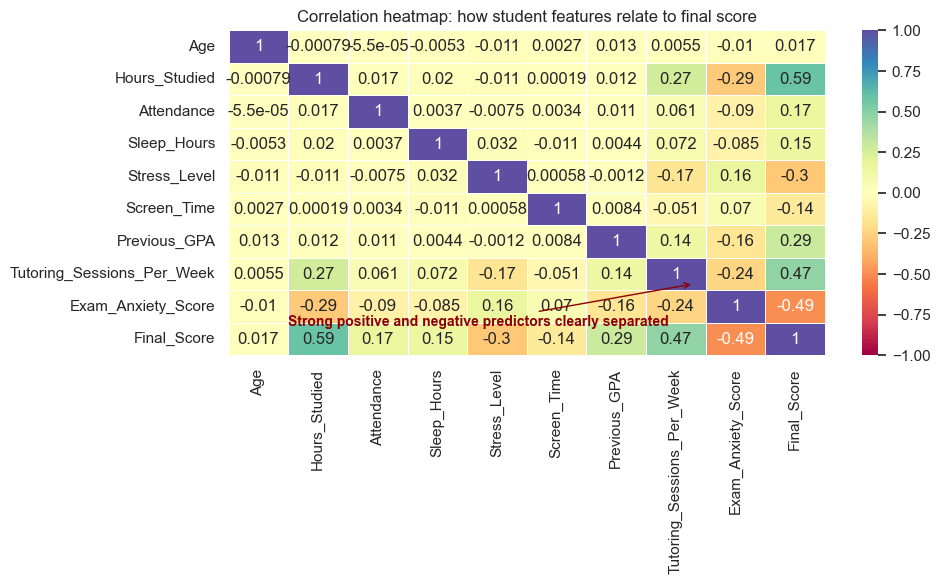

In [324]:
fig, ax = plt.subplots(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Spectral",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    ax=ax
)

ax.set_title("Correlation heatmap: how student features relate to final score")
ax.annotate(
    "Strong positive and negative predictors clearly separated",
    xy=(0.78, 0.22), xycoords="axes fraction",
    xytext=(0.10, 0.09), textcoords="axes fraction",
    arrowprops={"arrowstyle": "->", "color": "darkred"},
    fontsize=10,
    fontweight="bold",
    color="darkred"
)
fig.tight_layout()
plt.show()


## Key Insights from the Correlation Heatmap

### Positive Correlations
- Hours_Studied has the strongest positive relationship with Final_Score, stronger than Previous_GPA or Tutoring_Sessions_Per_Week.
- Tutoring sessions and Previous_GPA also support success, but less strongly than study time.

### Negative Correlations
- Exam_Anxiety_Score shows a stronger negative relationship than Stress_Level, and both are clearly more harmful than Screen_Time.
- Screen_Time has only a weak negative effect compared to the stronger psychological predictors.



## 2. Does study time strongly predict academic performance?
#### why scatterplot?
#### Scatter plots help visualize the relationship between two continuous numerical variables and identify trends, clusters, and variability. This chart makes it possible to observe:
    - correlation direction.
    - relationship strength.
    - clusters.
    - outliers.
#### I also considered using a line plot, but a scatterplot better represents individual student variation.

### a. Hours studies vs Final score

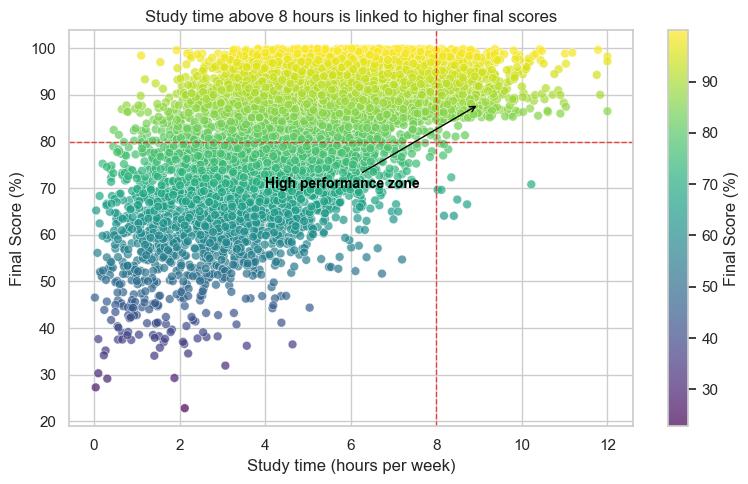

In [325]:
fig, ax = plt.subplots(figsize=(8,5))

scatter = ax.scatter(
    df_cleaned["Hours_Studied"],
    df_cleaned["Final_Score"],
    c=df_cleaned["Final_Score"],
    cmap="viridis",
    alpha=0.7,
    edgecolors="white",
    linewidth=0.4,
    s=40
)

ax.axvline(8, color="red", linestyle="--", linewidth=1, alpha=0.7)
ax.axhline(80, color="red", linestyle="--", linewidth=1, alpha=0.7)
ax.annotate(
    "High performance zone",
    xy=(9, 88),
    xytext=(4, 70),
    arrowprops={"arrowstyle": "->", "color": "black"},
    fontsize=10,
    fontweight="bold",
    color="black"
)

ax.set_title("Study time above 8 hours is linked to higher final scores")
ax.set_xlabel("Study time (hours per week)")
ax.set_ylabel("Final Score (%)")
fig.colorbar(scatter, ax=ax, label="Final Score (%)")
fig.tight_layout()
plt.show()


### DATA STORYTELLING ( Hours studied vs Final score)
- More hours studied is linked to higher final score, and this positive effect is stronger and more consistent than the negative effects seen with anxiety.
- Some students study a lot but still score lower, which shows that study time alone does not guarantee the highest result.
- High-Performance Zone combines higher hours and higher scores, while low performance is concentrated among students with fewer study hours.
- Compared to anxious or stressed students, the hours-studied effect is the clearest positive pattern in the data.
#### 1. Studying is the strongest positive factor affecting performance.
#### 2. However, study time is not sufficient on its own when psychological factors differ.


## Does exam anxiety reduce academic performance?
### b. Anxiety vs Final Score

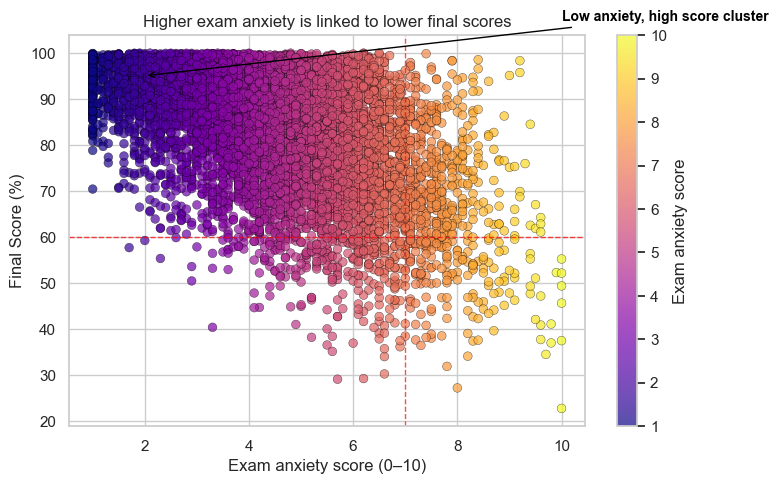

In [326]:
fig, ax = plt.subplots(figsize=(8,5))

scatter = ax.scatter(
    df_cleaned["Exam_Anxiety_Score"],
    df_cleaned["Final_Score"],
    c=df_cleaned["Exam_Anxiety_Score"],
    cmap="plasma",
    alpha=0.7,
    edgecolors="black",
    linewidth=0.3,
    s=40
)

ax.axvline(7, color="red", linestyle="--", linewidth=1, alpha=0.7)
ax.axhline(60, color="red", linestyle="--", linewidth=1, alpha=0.7)
ax.annotate(
    "Low anxiety, high score cluster",
    xy=(2, 95.05),
    xytext=(10, 107),
    arrowprops={"arrowstyle": "->", "color": "black"},
    fontsize=10,
    fontweight="bold",
    color="black"
)

ax.set_title("Higher exam anxiety is linked to lower final scores")
ax.set_xlabel("Exam anxiety score (0–10)")
ax.set_ylabel("Final Score (%)")
fig.colorbar(scatter, ax=ax, label="Exam anxiety score")
fig.tight_layout()
plt.show()


### DATA STORYTELLING ( Exam anxiety vs Final score)
- Higher exam anxiety is linked to lower final score, and the negative effect appears stronger and more consistent than the weak negative effect from Screen_Time.
- Low anxiety students are more likely to achieve high scores, while high anxiety students rarely reach the top performance band.
- Compared to hours studied, anxiety shows a sharper downward trend: students with moderate study time but high anxiety still have lower final scores.
#### 1. High anxiety is a stronger negative predictor than low study hours in this sample.
#### 2. Anxiety seems more harmful to final score than the average variation in study hours.


# 3. How are final scores distributed among students?
### Distribution plots "histogram" are used to understand:
- Score concentration.
- Skewness.
- Variability.
- Overall student performance distribution.
## a. Final score

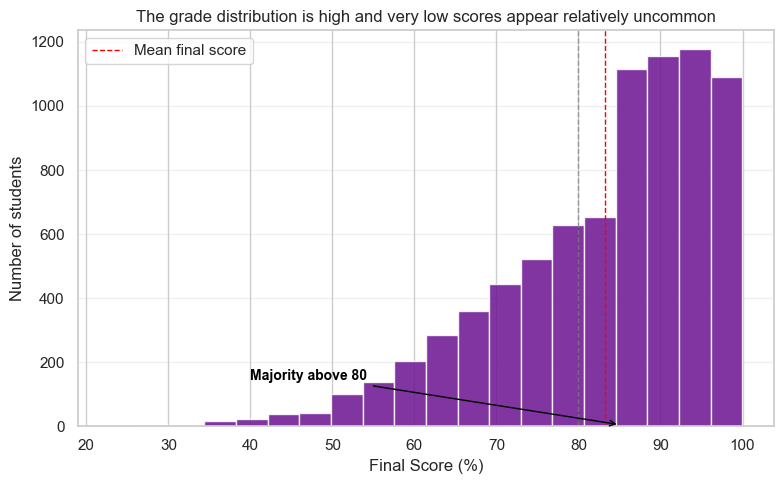

In [327]:
fig, ax = plt.subplots(figsize=(8,5))

ax.hist(
    df_cleaned["Final_Score"],
    bins=20,
    color="#6B1291",
    edgecolor="white",
    alpha=0.85
)
mean_score = df_cleaned["Final_Score"].mean()
ax.axvline(mean_score, color="red", linestyle="--", linewidth=1, label="Mean final score")
ax.axvline(80, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.set_title("The grade distribution is high and very low scores appear relatively uncommon")
ax.set_xlabel("Final Score (%)")
ax.set_ylabel("Number of students")
ax.grid(axis="y", alpha=0.3)
ax.annotate(
    "Majority above 80",
    xy=(85, 5),
    xytext=(40, 145),
    arrowprops={"arrowstyle": "->", "color": "black"},
    fontsize=10,
    fontweight="bold",
    color="black"
)
ax.legend()

fig.tight_layout()
plt.show()


### DATA STORYTELLING ( Distribution of final score ) - The level of difficulty of the educational system and the performance of the students as a whole
- Overall performance is high, with most students scoring above 80 and the upper range more populated than the lower range.
- The distribution is right-skewed, so strong performers outnumber weak performers.
- Compared to a balanced distribution, there are far more high scores than low scores, suggesting this cohort performs better than a uniform grade spread.



# 4. Does study method affect final scores?
### Boxplots help compare score distributions across different student groups and study methods "categorical groups". I tested using a bar chart showing averages only but the boxplot better reveals:
    - median differences.
    - variability.
    - possible outliers.
## a. stydy_Method vs Final_Score

C:\Users\Fatimalmurtadha\AppData\Local\Temp\ipykernel_4104\252569907.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


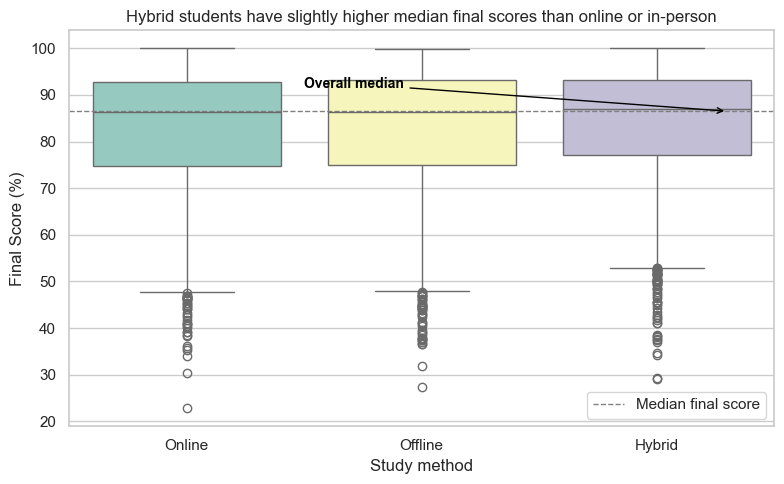

In [328]:
fig, ax = plt.subplots(figsize=(8,5))

sns.boxplot(
    data=df_cleaned,
    x="Study_Method",
    y="Final_Score",
    palette="Set3",
    ax=ax
)
median_score = df_cleaned["Final_Score"].median()
ax.axhline(median_score, color="gray", linestyle="--", linewidth=1, label="Median final score")
ax.annotate(
    "Overall median",
    xy=(2.3, median_score),
    xytext=(0.5, median_score + 5),
    textcoords="data",
    arrowprops={"arrowstyle": "->", "color": "black"},
    fontsize=10,
    fontweight="bold",
    color="black"
)
ax.set_title("Hybrid students have slightly higher median final scores than online or in-person")
ax.set_xlabel("Study method")
ax.set_ylabel("Final Score (%)")
ax.legend()

fig.tight_layout()
plt.show()


### DATA STORYTELLING ( Final score by study method "Online , Offline , Hybrid")
- Differences between study methods are relatively small, but Hybrid students appear to have a higher median than both Online and In-Person.
- The overlap between groups suggests study method matters less than individual effort and psychological state.
- Compared to Online and In-Person, Hybrid shows a slightly stronger score distribution and a tighter upper range.



# 5. How do psychological and academic factors predict final score?
### Regression scatter plots are used instead of a pairplot because they make the direction, strength, and slope of each predictor explicit.
A pairplot gives a broad correlation matrix, but it is less effective for comparing individual predictor impacts and building a clear, model-focused interpretation.


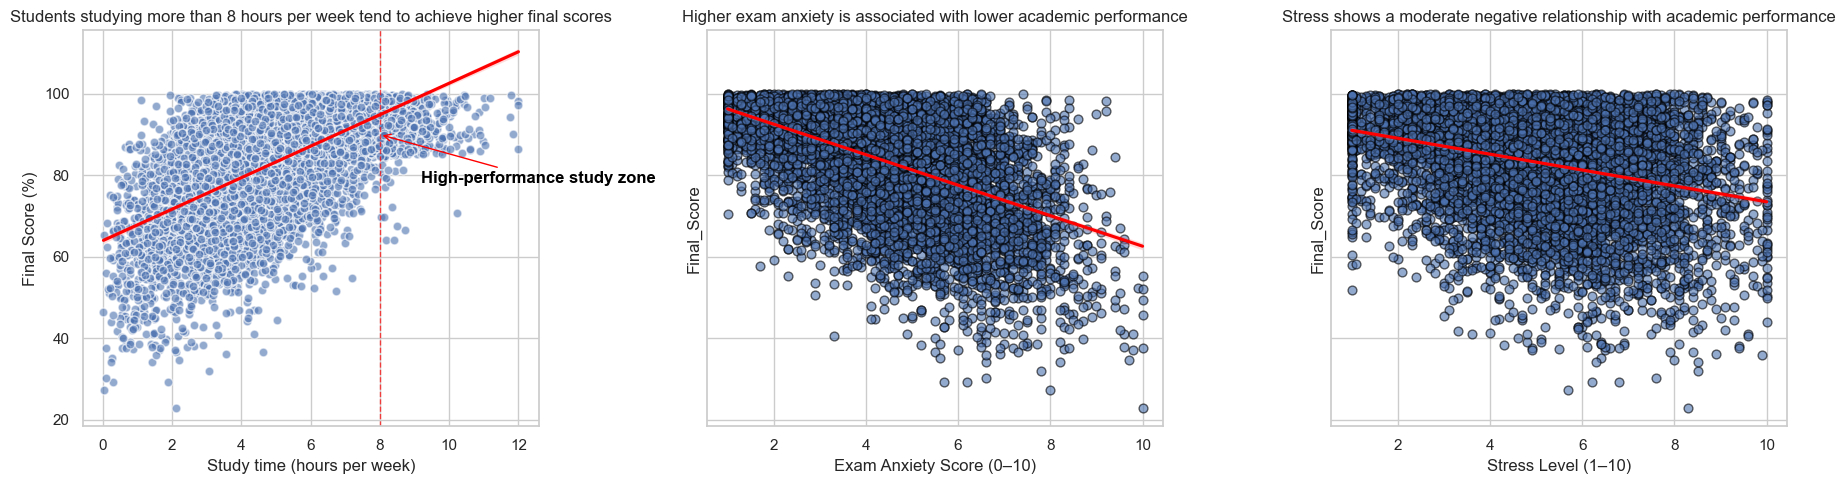

In [329]:
fig, axes = plt.subplots(ncols=3, figsize=(18,5), sharey=True)

sns.regplot(
    data=df_cleaned,
    x="Hours_Studied",
    y="Final_Score",
    scatter_kws={"alpha": 0.6, "s": 40, "edgecolor": "white"},
    line_kws={"color": "red"},
    ax=axes[0]
)
axes[0].set_title("Students studying more than 8 hours per week tend to achieve higher final scores")
axes[0].set_xlabel("Study time (hours per week)")
axes[0].set_ylabel("Final Score (%)")

sns.regplot(
    data=df_cleaned,
    x="Exam_Anxiety_Score",
    y="Final_Score",
    scatter_kws={"alpha": 0.6, "s": 40, "edgecolor": "black"},
    line_kws={"color": "red"},
    ax=axes[1]
)
axes[1].set_title("Higher exam anxiety is associated with lower academic performance")
axes[1].set_xlabel("Exam Anxiety Score (0–10)")

sns.regplot(
    data=df_cleaned,
    x="Stress_Level",
    y="Final_Score",
    scatter_kws={"alpha": 0.6, "s": 40, "edgecolor": "black"},
    line_kws={"color": "red"},
    ax=axes[2]
)
axes[2].set_title("Stress shows a moderate negative relationship with academic performance")
axes[2].set_xlabel("Stress Level (1–10)")

axes[0].axvline(8, color="red", linestyle="--", linewidth=1, alpha=0.7)
axes[0].annotate(
    "High-performance study zone",
    xy=(8, 90),
    xytext=(9.2, 78),
    textcoords="data",
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=12,
    fontweight="bold",
    color="black"
)

fig.tight_layout()
plt.show()


### DATA STORYTELLING (Regression scatter plots for predictor impact)
- Regression scatter plots make each predictor’s effect on `Final_Score` explicit through a fitted trend line.
- `Hours_Studied` shows the strongest positive slope, while `Exam_Anxiety_Score` and `Stress_Level` show negative slopes.
- This approach makes it easier to compare the magnitude of each predictor directly, instead of relying on a dense pairplot matrix.
- The pairplot was changed because it is useful for broad pairwise exploration, but it is less precise for contrasting the relative strength of core predictors and explaining why one predictor is more important than another.


# 10. Limitation of the Analysis
## Limitations of the Analysis

Although several meaningful patterns were identified, the dataset has important limitations.

- Correlation does not imply causation.
- The dataset does not measure motivation, teaching quality, or learning disabilities.
- Anxiety and stress levels may be self-reported and therefore subjective.
- The dataset may not represent students from all countries or educational systems.
- Some relationships may be influenced by hidden variables not included in the dataset.

Therefore, the findings should be interpreted as exploratory rather than definitive conclusions.

# 11. What the data can't tell us?
The dataset shows relationships between variables, but it cannot explain why these relationships exist.

For example:
- Students with high study hours may also have stronger discipline or better support systems.
- Lower anxiety may be the result of good performance rather than the cause of it.

The analysis identifies patterns, not causal truths.

## 12. Final Conclusions

### The analysis suggests that academic performance is influenced by a combination of:
- Study effort
- Psychological wellbeing
- Academic history
- Learning habits

### Comparative findings:
- Hours studied is the strongest positive factor in this dataset.
- Exam anxiety has the strongest negative effect, more than stress or lifestyle variables.
- Previous GPA remains a reliable predictor, but it is less dominant than hours studied.
- Study method shows only modest differences, with Hybrid slightly outperforming Online and In-Person.

### Key findings:
- Academic success cannot be explained by a single variable alone.
- The data compares multiple factors and shows that both psychological and behavioral variables matter.

### This project demonstrates how exploratory data analysis can uncover meaningful patterns in educational datasets.
